In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob
from arcgis.gis import GIS
#gis = GIS("http://deldev.maps.arcgis.com", "demos_deldev", "DelDevs12")
gis = GIS(profile="your_online_profile")

In [2]:
from arcgis.features.manage_data import merge_layers

In [3]:
office_item = gis.content.get('1f163950afbb4bf39f3ee67cf411761d')

In [4]:
satellite_item = gis.content.get('6a5feb1c64624f14aae842fc48f7c0ce')

<Item title:"Esri Regional Offices US" type:Feature Layer Collection owner:lsarow_eoe>
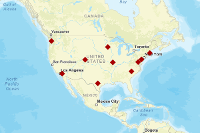

In [5]:
office_item

<Item title:"Esri Global Offices public view" type:Feature Layer Collection owner:lsarow_eoe>
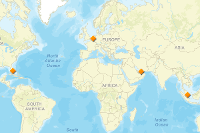

In [6]:
satellite_item

In [ ]:
esri_offices = office_item.layers[0]
satellite_office_lyr = satellite_item.layers[0]

In [ ]:
#[fld['name'] for fld in esri_offices.properties.fields], [fld['name'] for fld in satellite_office_lyr.properties.fields]

In [ ]:
from datetime import datetime

result = merge_layers(input_layer=esri_offices, 
                      merge_layer=satellite_office_lyr, 
                      merging_attributes=["Address_1 Match Address_1"],
                      output_name="test_" + str(datetime.now().microsecond))

In [ ]:
assert isinstance(result, Item)
result

In [ ]:
result.delete()

In [ ]:
result = merge_layers(input_layer=esri_offices, 
                      merge_layer=satellite_office_lyr, 
                      merging_attributes=["State Match State"])

In [ ]:
assert isinstance(result, FeatureCollection)
result

In [ ]:
result = merge_layers(input_layer=esri_offices, 
                      future=True,
                      merge_layer=satellite_office_lyr, 
                      merging_attributes=["State Match State"])
assert isinstance(result, GPJob)
assert isinstance(result.result(), FeatureCollection)

In [ ]:
result = merge_layers(input_layer=esri_offices, 
                      future=True,
                      merge_layer=satellite_office_lyr, 
                      merging_attributes=["State Match State"],
                     output_name="test_" + str(datetime.now().microsecond))
assert isinstance(result, GPJob)
assert isinstance(result.result(), Item)
assert result.result().delete()

#### Test Overwrite

In [ ]:
import sys
sys.path.insert(0, r"C:\\ipython_workfolder\\geosaurus\\src")
from arcgis.gis import GIS

portal = GIS(profile="your_portal_profile", verify_cert=False,)

In [ ]:
cougar_item = portal.content.get("71f20aa845f64f129a78303e6b5039c6")
vegetation = cougar_item.layers[5]
forest = cougar_item.layers[7]

In [ ]:
result = merge_layers(input_layer=vegetations, 
                      merge_layer=forest, 
                      merging_attributes=["area Match area"],
                      output_name="test_overwrite")

In [ ]:
fl_to_overwrite = portal.content.get(result.id).layers[0]
fl_to_overwrite

In [ ]:
overwrite = merge_layers(input_layer=vegetations, 
                      merge_layer=forest, 
                      merging_attributes=["area Match area"],
                      output_name=fl_to_overwrite,
                      context={"overwrite":True})

In [ ]:
overwrite.layers

In [ ]:
overwrite.delete()